In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn  as sns

In [10]:
df=pd.read_csv('retail_store_inventory.csv')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [12]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Sort the data by Date
df = df.sort_values(by='Date')

# Encode categorical variables (e.g., Category, Region, Weather, Seasonality)
# For simplicity, we can use pandas get_dummies (One-Hot Encoding)
df_encoded = pd.get_dummies(df, columns=['Category', 'Region', 'Weather Condition', 'Seasonality'], drop_first=True)


In [13]:
# 1. Time Features
df_encoded['DayOfWeek'] = df_encoded['Date'].dt.dayofweek
df_encoded['Month'] = df_encoded['Date'].dt.month
df_encoded['Day'] = df_encoded['Date'].dt.day

# 2. Lag Features (e.g., Units Sold 1 day ago, 7 days ago)
# Note: In a real scenario, you'd calculate lags per Store and Product
df_encoded['Units_Sold_Lag_1'] = df_encoded.groupby(['Store ID', 'Product ID'])['Units Sold'].shift(1)
df_encoded['Units_Sold_Lag_7'] = df_encoded.groupby(['Store ID', 'Product ID'])['Units Sold'].shift(7)

# Drop rows with NaN values created by lagging
df_encoded = df_encoded.dropna() 


In [14]:
# Let's say we use the last 20% of dates as our test set
split_date = df_encoded['Date'].quantile(0.8)

train = df_encoded[df_encoded['Date'] < split_date]
test = df_encoded[df_encoded['Date'] >= split_date]

# Define features (X) and Target (y) - Target is 'Units Sold'
drop_cols = ['Date', 'Store ID', 'Product ID', 'Units Sold', 'Demand Forecast']
X_train = train.drop(columns=drop_cols)
y_train = train['Units Sold']

X_test = test.drop(columns=drop_cols)
y_test = test['Units Sold']


In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Initialize the model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
predictions = model.predict(X_test)


Mean Absolute Error (MAE): 69.28
Root Mean Squared Error (RMSE): 88.80


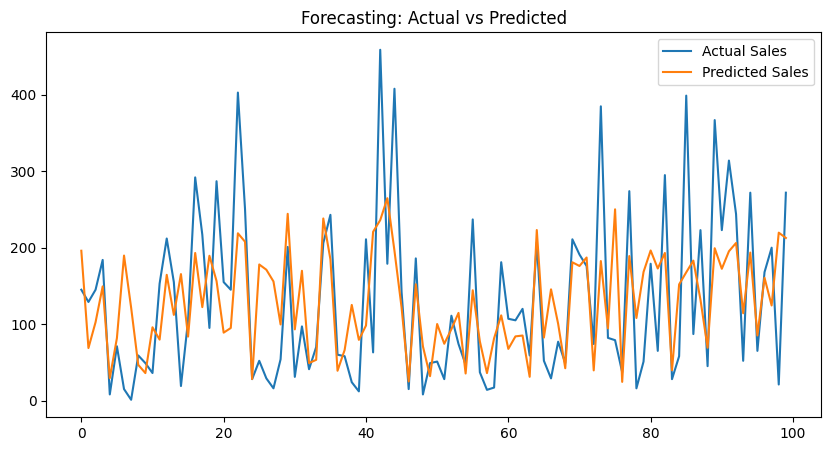

In [ ]:
# Calculate Errors
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

#Plot Actual vs Predicted for a quick visual check
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label='Actual Sales')
plt.plot(predictions[:100], label='Predicted Sales')
plt.legend()
plt.title('Forecasting: Actual vs Predicted')
plt.show()


In [ ]:
!pip install tensorflow scikit-learn

In [ ]:
from sklearn.preprocessing import MinMaxScaler
daily_sales = df.groupby('Date')['Units Sold'].sum().reset_index()
daily_sales = daily_sales.sort_values('Date')
# Extract the target values as a numpy array
dataset = daily_sales['Units Sold'].values.reshape(-1, 1)
# 2. Scale the data between 0 and 1 (Crucial for LSTMs)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

Time Step Sequence

In [ ]:
def create_sequences(data, time_steps=30):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps), 0])
        y.append(data[i + time_steps, 0])
    return np.array(X), np.array(y)
time_steps = 30 # Look back 30 days
X, y = create_sequences(scaled_data, time_steps)


X = X.reshape(X.shape[0], X.shape[1], 1)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense,Dropout
# Use the first 80% for training, 20% for testing
split_index = int(len(X) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# 3. Build the LSTM Model
model = Sequential()

# First LSTM Layer
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2)) # Prevents overfitting

# Second LSTM Layer
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Output Layer (Predicts 1 value)
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

# 4. Train the Model
print("Training LSTM Model...")
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training LSTM Model...
Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.0564 - val_loss: 0.0317
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0273 - val_loss: 0.0273
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0262 - val_loss: 0.0266
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0276 - val_loss: 0.0266
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0279 - val_loss: 0.0266
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0273 - val_loss: 0.0265
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0267 - val_loss: 0.0278
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0272 - val_loss: 0.0265
Epoch 9/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0266 - val_loss: 0.0263
Epoch 10/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0267 - val_loss: 0.0263
Epoch 11/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0259 - val_loss: 0.0268
Epoch 12/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step


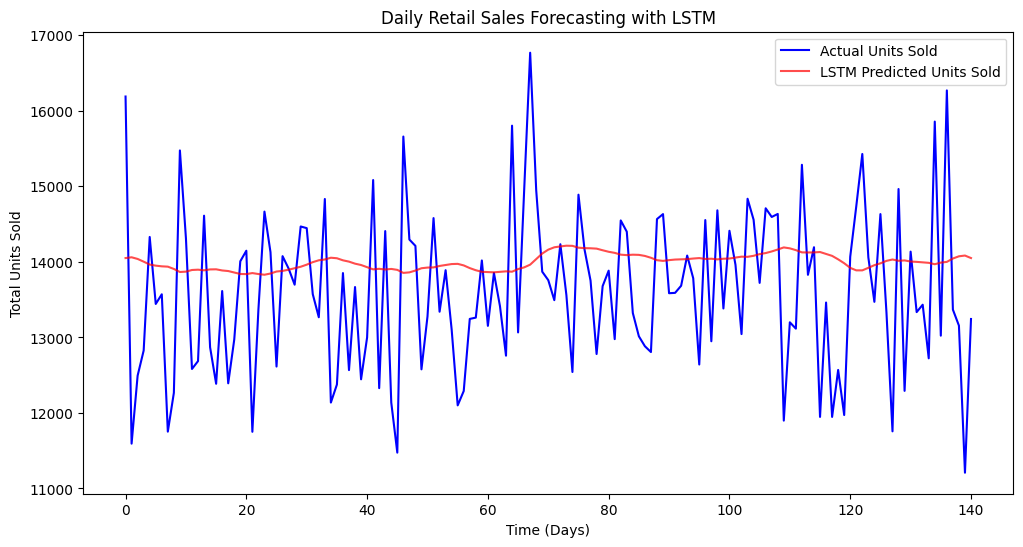

In [ ]:
# Predict using the test set
predicted_sales_scaled = model.predict(X_test)

# Reverse the scaling to get actual numbers back
predicted_sales = scaler.inverse_transform(predicted_sales_scaled)
actual_sales = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(actual_sales, label='Actual Units Sold', color='blue')
plt.plot(predicted_sales, label='LSTM Predicted Units Sold', color='red', alpha=0.7)
plt.title('Daily Retail Sales Forecasting with LSTM')
plt.xlabel('Time (Days)')
plt.ylabel('Total Units Sold')
plt.legend()
plt.show()
